## Run DOLPHOT on simulated Rosesim images and do artificial star injection tests

In [1]:
# Import packages
%load_ext autoreload
%autoreload 2

import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import os
from astropy.io import fits
from kuaizi.display import display_single

import romanisim
import romanisim.parameters
import romanisim.bandpass
from astropy.table import Table, hstack, vstack
import astropy.units as u

import sys
sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
from display import show_image_wcs

from scipy.stats import binned_statistic
import kuaizi
kuaizi.set_matplotlib(style='nature', usetex=False, dpi=90)

## 1. Check DOLPHOT residuals

In [2]:
exptime = 642
host = 'ngc253'
# host = 'cena'

In [3]:
os.chdir(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/{host}/')
!pwd

/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/ngc253


/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/ngc253


(<Figure size 900x360 with 2 Axes>,
 <Axes: >,
 {'norm': <astropy.visualization.mpl_normalize.ImageNormalize at 0x7f828554df90>})

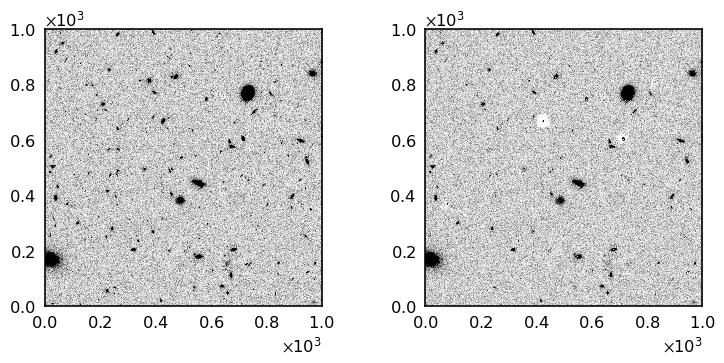

(<Figure size 900x360 with 2 Axes>,
 <Axes: >,
 {'norm': <astropy.visualization.mpl_normalize.ImageNormalize at 0x7f91064a4d70>})

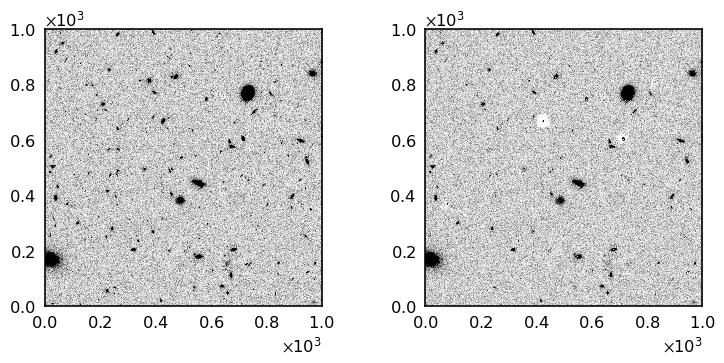

In [4]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))

hdu = fits.open(f'./F158_{exptime}s.fits')
_, _, norm = show_image_wcs(hdu[0].data[:1000, :1000], fig=fig, ax=ax1, percl=99)

# The residual image after DOLPHOT. You'll see lots of point sources disappeared.
hdu = fits.open(f'./{host}_{exptime}s/{host}_{exptime}s.phot.2.res.fits')
show_image_wcs(hdu[0].data[:1000, :1000], fig=fig, ax=ax2, scale_args=norm)

In [5]:
# fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))

# exptime = 10272
# # hdu = fits.open(f'../raw/F158_{exptime}s.fits')
# hdu = fits.open(f'./F158_{exptime}s.fits')
# _, _, norm = show_image_wcs(hdu[0].data[:1000, :1000], fig=fig, ax=ax1)#, percl=93)

# # hdu = fits.open(f'./F158_{exptime}s.fits')
# hdu = fits.open(f'./ngc253_{exptime}s/ngc253_{exptime}s.phot.1.res.fits')
# show_image_wcs(hdu[0].data[:1000, :1000], fig=fig, ax=ax2)#, scale_args=norm)

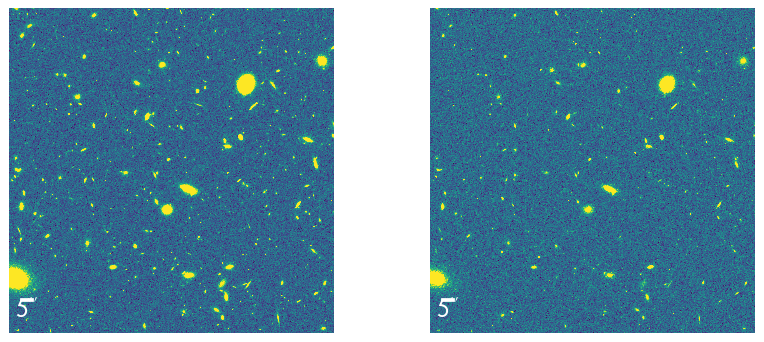

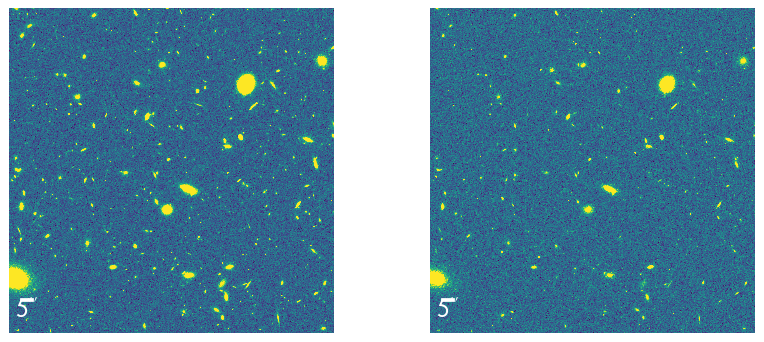

In [6]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))
exptime = 5136
hdu = fits.open(f'./raw/F158_{exptime}s.fits')
display_single(hdu[0].data[:1000, :1000], ax=ax1);

exptime = 642
hdu = fits.open(f'./raw/F158_{exptime}s.fits')
display_single(hdu[0].data[:1000, :1000], ax=ax2);

plt.tight_layout()

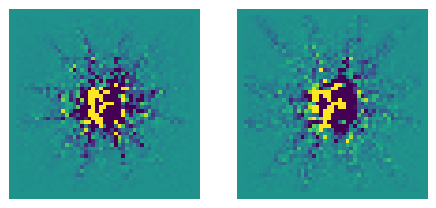

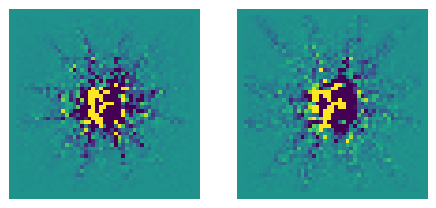

In [7]:
# This shows the "correction" term to the fiducial Roman PSF templates, as we downloaded when installing DOLPHOT
exptime = 642
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(6, 3))
hdu = fits.open(f'{host}_{exptime}s.phot.1.psf.fits')
display_single(hdu[0].data, xsize=4, ysize=4, scale_bar=False, ax=ax1);
hdu = fits.open(f'{host}_{exptime}s.phot.2.psf.fits')
display_single(hdu[0].data, xsize=4, ysize=4, scale_bar=False, ax=ax2);

## 2. Check the DOLPHOT catalog

In [8]:
from rosesim.utils import read_dolphot_cat, xmatch_true_meas

def quality_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = cat['snr_f158'] > snr
    flag &= cat['snr_f106'] > snr
    flag &= (cat['crowd_f106'] < crowd['f106'])
    flag &= (cat['crowd_f158'] < crowd['f158'])
    # flag &= (cat['qflag_f158'] <= 4)
    # flag &= (cat['qflag_f106'] <= 4)
    flag &= (cat['obj_type'] <= 2)
    flag &= (cat['pass_det'] < 3)
    return flag


def point_source_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = quality_cut(cat, snr=snr, crowd=crowd, sharp=sharp)
    flag &= (cat['sharp_f106']**2 < sharp['f106'])
    flag &= (cat['sharp_f158']**2 < sharp['f158'])
    flag &= (cat['chi_f106'] < 3)
    flag &= (cat['chi_f158'] < 3)
    return flag

Exptime: 642.0 Filters: ['F106', 'F158']


Text(0, 0.5, 'sharp')

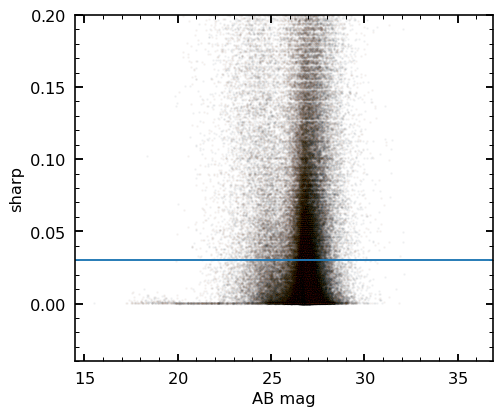

Exptime: 642.0 Filters: ['F106', 'F158']


Text(0, 0.5, 'sharp')

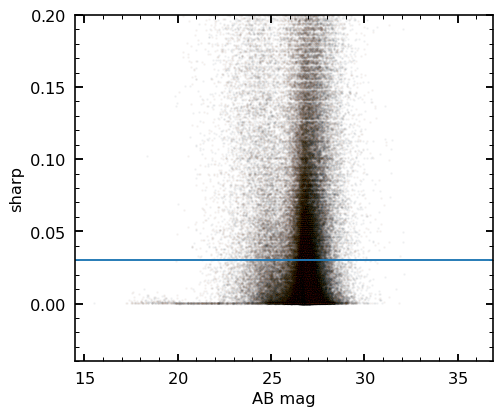

In [9]:
exptime = 642
os.chdir(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/{host}/')
cat = read_dolphot_cat(f'./{host}_{exptime}s.phot', f'./{host}_{exptime}s.phot.columns', fake=False)

plt.scatter(cat['mag_ab_f106'], abs(cat['sharp_f106'])**2, s=1, alpha=0.04)
plt.scatter(cat['mag_ab_f158'], abs(cat['sharp_f158'])**2, s=1, alpha=0.04)
plt.ylim(-0.04, 0.2)
plt.axhline(0.03)
plt.xlabel('AB mag')
plt.ylabel('sharp')

Exptime: 642.0 Filters: ['F106', 'F158']


Text(0, 0.5, 'crowd')

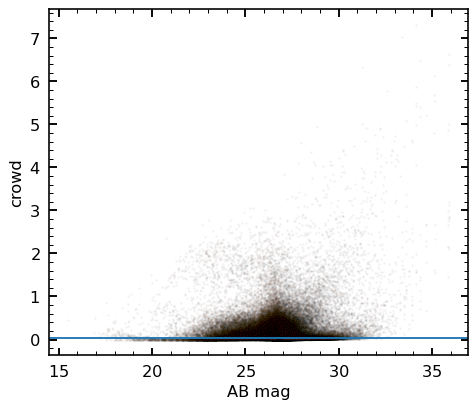

In [14]:
exptime = 642
os.chdir(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/{host}/')
cat = read_dolphot_cat(f'./{host}_{exptime}s.phot', f'./{host}_{exptime}s.phot.columns', fake=False)

plt.scatter(cat['mag_ab_f106'], (cat['crowd_f106']), s=1, alpha=0.04)
plt.scatter(cat['mag_ab_f158'], (cat['crowd_f158']), s=1, alpha=0.04)
# plt.ylim(-0.04, 0.2)
plt.axhline(0.03)
plt.xlabel('AB mag')
plt.ylabel('crowd')

In [22]:
npix  = 5
1 / (50 * npix * 0.11**2) # star per arcsec2

0.3305785123966942

In [24]:
200000 / (3600**2)

0.015432098765432098

In [16]:
cat['good_flag'] = quality_cut(cat, snr=3, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03})
cat['star_flag'] = point_source_cut(cat, snr=3, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03})

In [17]:
np.sum(cat['star_flag']), np.sum(cat['good_flag'])

(np.int64(12422), np.int64(34385))

(np.int64(12218), np.int64(37075))

In [18]:
from astropy.wcs import WCS
w = WCS(fits.open(f'./F158_{exptime}s.fits')[0].header)
cat['ra'], cat['dec'] = w.all_pix2world(cat['x'], cat['y'], 1)
cat[:3]

ext,chip,x,y,chi,snr,sharp,round,major_axis,crowd,obj_type,pass_det,counts_f106,sky_f106,mag_ab_f106,mag_err_f106,chi_f106,snr_f106,sharp_f106,round_f106,crowd_f106,qflag_f106,counts_f158,sky_f158,mag_ab_f158,mag_err_f158,chi_f158,snr_f158,sharp_f158,round_f158,crowd_f158,qflag_f158,good_flag,star_flag,ra,dec
int64,int64,float64,float64,float64,float64,float64,float64,int64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,bool,bool,float64,float64
0,1,2429.88,3102.96,0.0,422.1,-0.266,3.838,160,0.597,1,1,11600000.0,10726.93,15.709430558443351,0.003,1.0,331.1,-0.65,1.406,0.448,12,2360000.0,11999.75,17.455984364991373,0.004,1.0,261.8,-0.144,4.628,0.644,12,False,False,201.3674447291496,-42.998273439980515
0,1,2427.47,3104.03,5.67,710.9,-0.65,2.345,160,0.207,1,2,4040000.0,7544.71,16.854622118734135,0.003,6.92,419.7,-0.627,2.575,0.387,12,4060000.0,11066.48,16.866949288473656,0.002,2.63,573.8,-0.661,2.221,0.113,12,False,False,201.36734404514442,-42.998240742891035
0,1,1868.24,1329.51,3.59,844.5,0.006,0.016,45,0.015,1,1,2000000.0,952.64,17.618000542350696,0.002,4.3,473.5,-0.027,0.025,0.014,12,3290000.0,1205.53,17.095274627541706,0.002,2.46,699.3,0.03,0.01,0.015,12,False,False,201.3439570391519,-43.05245917550645


ext,chip,x,y,chi,snr,sharp,round,major_axis,crowd,obj_type,pass_det,counts_f106,sky_f106,mag_ab_f106,mag_err_f106,chi_f106,snr_f106,sharp_f106,round_f106,crowd_f106,qflag_f106,counts_f158,sky_f158,mag_ab_f158,mag_err_f158,chi_f158,snr_f158,sharp_f158,round_f158,crowd_f158,qflag_f158,good_flag,star_flag,ra,dec
int64,int64,float64,float64,float64,float64,float64,float64,int64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,bool,bool,float64,float64
0,1,2429.42,3103.0,0.0,434.8,-0.056,3.857,160,0.733,1,1,14000000.0,10158.96,15.505255442315054,0.003,1.0,365.4,0.026,1.202,0.448,12,2210000.0,10840.38,17.527283688203866,0.005,1.0,235.7,-0.087,4.865,0.838,12,False,False,11.88563937908806,-25.270405536479164
0,1,2427.47,3104.01,5.16,680.9,-0.694,2.428,160,0.275,1,2,3680000.0,6219.39,16.955955984826854,0.003,5.28,390.3,-0.605,2.834,0.51,12,3970000.0,10382.31,16.891288105508856,0.002,4.96,557.9,-0.739,2.214,0.155,12,False,False,11.885573491053394,-25.270374674282955
0,1,2431.93,3102.43,11.63,643.0,-0.576,3.245,160,0.318,1,2,1930000.0,6667.87,17.656682258991214,0.003,13.78,349.2,-0.537,4.317,0.561,12,3040000.0,10821.12,17.18108041339476,0.002,7.99,539.9,-0.601,2.536,0.162,12,False,False,11.885724189293326,-25.270422954501853


In [19]:
from astropy.coordinates import SkyCoord
true_cat = Table.read('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/gal_28mag/temp/sky_table.ecsv')
# true_cat = Table.read(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/temp/sky_table_sky_jaguar_trilegal_cena_sizecut_642s.ecsv')
# true_cat = true_cat[true_cat['type'] == 'PSF']
out, meas_m, true_m = xmatch_true_meas(true_cat, cat, radius=0.4 * u.arcsec)

In [20]:
len(true_cat), len(out), len(cat)

(22085, 0, 78003)

(22085, 3005, 83580)

(0.0, 1.1)

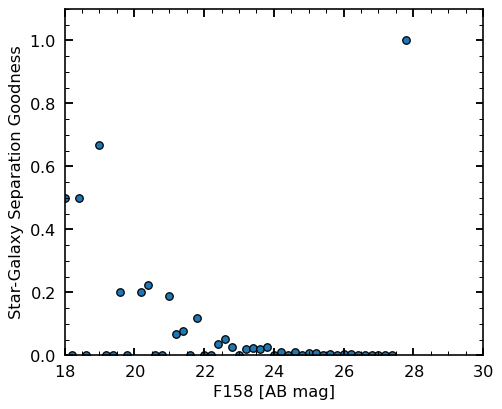

(0.0, 1.1)

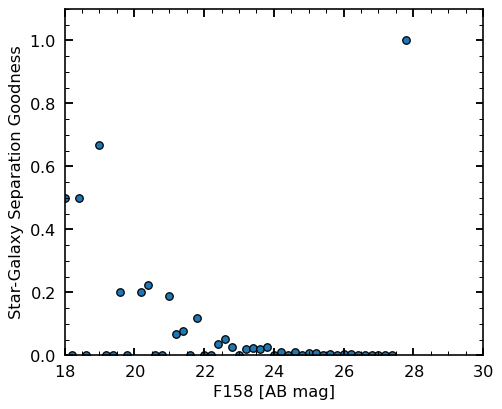

In [21]:
comp_bins = np.arange(17.5, 29.6, 0.2)
res = binned_statistic(-2.5 * np.log10(out['true_F158']), 
                       out['true_type'] == 'PSF', 
                       bins=comp_bins, statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
plt.scatter(mag, comp)

plt.ylabel('Star-Galaxy Separation Goodness')
plt.xlabel('F158 [AB mag]')

plt.xlim(18, 30)
plt.ylim(0, 1.1)

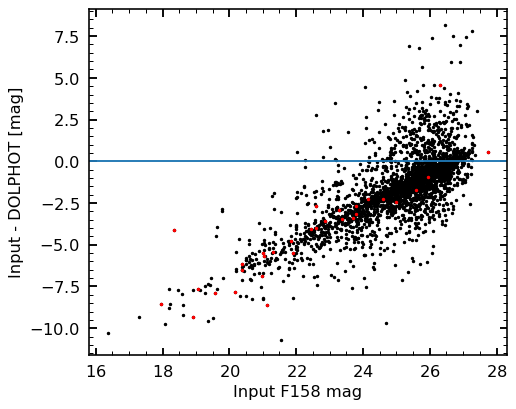

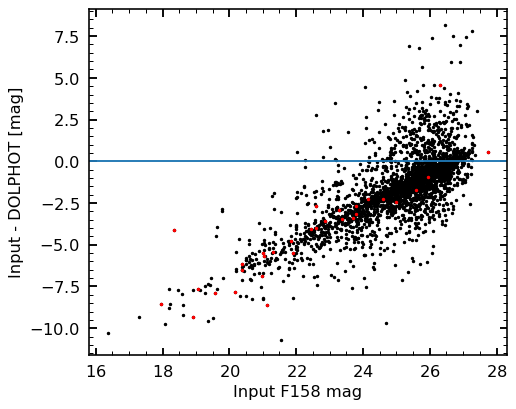

In [22]:
plt.scatter(-2.5 * np.log10(out['true_F158']), -2.5 * np.log10(out['true_F158']) - out['meas_mag_ab_f158'], s=3, color='k')

flag = out['true_type'] == 'PSF'
plt.scatter(-2.5 * np.log10(out[flag]['true_F158']), 
            -2.5 * np.log10(out[flag]['true_F158']) - out[flag]['meas_mag_ab_f158'], s=3, color='r')

# plt.ylim(-0.4, 0.4)

plt.xlabel('Input F158 mag')
plt.ylabel('Input - DOLPHOT [mag]')
plt.axhline(0)

## 3. Artificial Star Tests to derive completeness and photometric uncertainties

We use a function `quality_cut` to cull the catalog. If the `good_flag` is true, it passes the QA criteria in the `quality_cut` function. See here for more information on QA cuts: https://dolphot-jwst.readthedocs.io/en/latest/post-processing/catalogs.html

We also assume that the oc

In [48]:
from rosesim.utils import read_dolphot_cat, delta_m_scatter_vs_mag, logistic_completeness, mag_uncertainty_func, fit_logistic_completeness

In [49]:
pwd

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/ngc253'

In [66]:
# Here we load the AST output catalog,
exptime = 642 # 5136
# exptime = 5136
fake = read_dolphot_cat(f'./fake_{exptime}s.fake', f'./{host}_{exptime}s.phot.columns', fake=True)
# fake = read_dolphot_cat(f'./ngc253_{exptime}s/ngc253_{exptime}s.fake', f'./ngc253_{exptime}s.phot.columns', fake=True)
# fake2 = read_dolphot_cat(f'./ngc253_{exptime}s/ngc253_{exptime}s.fake.1', f'./ngc253_{exptime}s.phot.columns', fake=True)

# We apply QA cuts
fake['good_flag'] = point_source_cut(fake, snr=3, crowd={'f158': 0.5, 'f106': 0.5}, 
                                     sharp={'f158': 0.03, 'f106': 0.03})
len(fake)

Filters: ['F106', 'F158']
Exptime: 642.0 Filters: ['F106', 'F158']


80019

### 3.1 Completeness

In [67]:
# fake['good_flag'] = quality_cut(fake, snr=3, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}) 

Best fit completeness for f106: 26.86137423810115 0.48497726525693097
Best fit completeness for f158: 26.49710715971947 0.4727934700800887


Text(0.5, 1.0, 'High Galactic Latitude Field (NGC 253)')

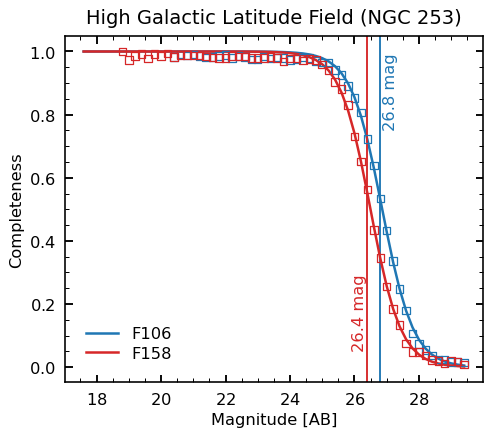

In [68]:
comp_bins = np.arange(17.5, 29.6, 0.2)
mag_50_dict = {}
colors = {'f106': 'C0', 'f158': 'C3'}

filt = 'f106'
res = binned_statistic(fake[f'mag_true_{filt}'], (np.isfinite(fake[f'mag_ab_{filt}']) & fake['good_flag']), bins=comp_bins, statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
plt.scatter(mag, comp, marker='s', fc='none', ec=colors[filt], zorder=10)
print(f'Best fit completeness for {filt}:', *fit_logistic_completeness(mag, comp)[0])
comp_pred = logistic_completeness(mag, *fit_logistic_completeness(mag, comp)[0])
mag_50_dict[filt] = mag[np.argmin(abs(comp_pred - 0.5))]
plt.plot(mag, comp_pred, label=filt.upper(), lw=2, c=colors[filt])
plt.axvline(mag_50_dict[filt], c=colors[filt])
plt.text(mag_50_dict[filt]+0.1, 0.75, f'{mag_50_dict[filt]:.1f} mag', c=colors[filt], rotation=90, ha='left', va='bottom')


filt = 'f158'
res = binned_statistic(fake[f'mag_true_{filt}'], (np.isfinite(fake[f'mag_ab_{filt}']) & fake['good_flag']), bins=comp_bins, statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
plt.scatter(mag, comp, marker='s', fc='none', ec=colors[filt], zorder=10)
print(f'Best fit completeness for {filt}:', *fit_logistic_completeness(mag, comp)[0])
comp_pred = logistic_completeness(mag, *fit_logistic_completeness(mag, comp)[0])
mag_50_dict[filt] = mag[np.argmin(abs(comp_pred - 0.5))]
plt.plot(mag, comp_pred, label=filt.upper(), lw=2, c=colors[filt])
plt.axvline(mag_50_dict[filt], c=colors[filt])
plt.text(mag_50_dict[filt], 0.05, f'{mag_50_dict[filt]:.1f} mag', c=colors[filt], rotation=90, ha='right', va='bottom')


plt.legend()
plt.xlabel('Magnitude [AB]')
plt.ylabel('Completeness')
plt.title('High Galactic Latitude Field (NGC 253)')

### 3.2 Photometric uncertainty

Best fit in f106 : [ 0.33849183 -9.63146925]
Best fit in f158 : [ 0.33611677 -9.50851665]

Photometric uncertainty dict:
{'f106': array([ 0.33849183, -9.63146925]), 'f158': array([ 0.33611677, -9.50851665])}


(20.0, 29.0)

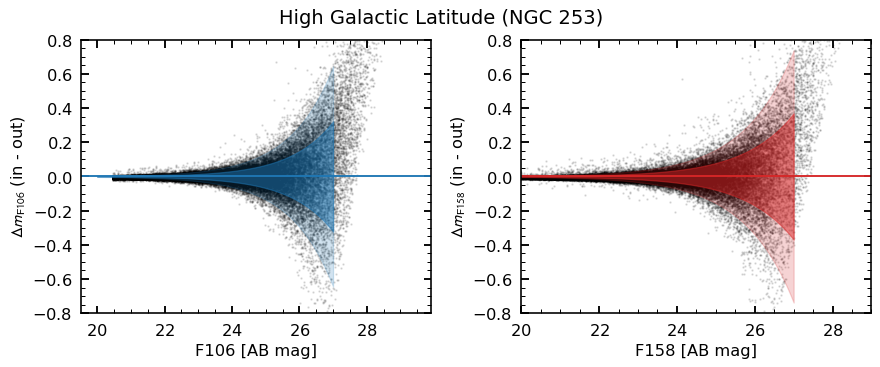

In [71]:
bands = ['f106', 'f158']
fig, axes = plt.subplots(1, len(bands), figsize=(10, 4))

coeffs_dict = {}

fake_good = fake[fake['good_flag']]
for i, filt in enumerate(bands):
    # Fit for a relation between mag and mag_err
    delta_m = fake_good[f'mag_true_{filt}'] - fake_good[f'mag_ab_{filt}']
    mag_bins = np.arange(23.0, 27, 0.3)
    scatter_tab = delta_m_scatter_vs_mag(
        fake_good[f'mag_true_{filt}'], delta_m,
        mag_bins=mag_bins, clip_sigma=3.0,
        clip_iters=3, method="mad", min_per_bin=20,
    )
    flag = (scatter_tab['mag_center'] <= 27) & ~np.isnan(scatter_tab['scatter'])
    coeffs_dict[filt] = np.polyfit(scatter_tab['mag_center'][flag], np.log10(scatter_tab['scatter'][flag]), 1)
    print(f'Best fit in {filt} :', coeffs_dict[filt])

    plt.sca(axes[i])
    plt.scatter(fake_good[f'mag_true_{filt}'], delta_m,  s=1, c='k', alpha=0.1)
    _x = np.linspace(20, 27, 100)
    sigma_pred = 10**(coeffs_dict[filt][0] * _x + coeffs_dict[filt][1])
    plt.fill_between(_x, sigma_pred, -sigma_pred, alpha=0.5, color=colors[filt])
    plt.fill_between(_x, sigma_pred * 2, -sigma_pred * 2, alpha=0.2, color=colors[filt])
    plt.axhline(0, color=colors[filt])
    plt.ylim(-0.8, 0.8)
    # plt.ylim(-0.1, 0.1)
    plt.xlabel(f'{filt.upper()} [AB mag]')
    plt.ylabel(r'$\Delta m_{\rm ' + filt.upper() + '}$ (in - out)')

plt.tight_layout()
plt.suptitle('High Galactic Latitude (NGC 253)', y=1.02)
print('\nPhotometric uncertainty dict:')
print(coeffs_dict)

plt.xlim(20, 29)


## Compile the whole thing

Text(0.5, 1.07, 'NGC 253 (Low Galactic Latitutde)\n (no stellar halo yet)')

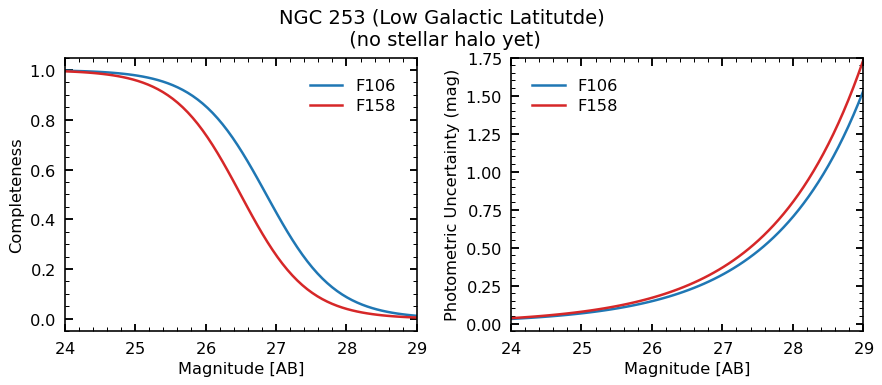

In [59]:
completeness_dict = {'F106': [26.861374163343974, 0.4849778783627637], 
                     'F158': [26.497107133874497, 0.47279379137194777]} # HLWAS depth
mag_uncertainty_dict = {'F106': [0.33849183, -9.63146925], 
                        'F158': [0.33611677, -9.50851665]} # HLWAS depth, DOLPHOT

fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))

plt.sca(ax1)
mag = np.linspace(22, 29, 100)
plt.plot(mag, logistic_completeness(mag, *completeness_dict['F106']), label='F106', color=colors['f106'], lw=2)
plt.plot(mag, logistic_completeness(mag, *completeness_dict['F158']), label='F158', color=colors['f158'], lw=2)
plt.xlim(24, 29)
plt.legend()
plt.xlabel('Magnitude [AB]')
plt.ylabel('Completeness')
plt.ylim(-0.05, 1.05)

plt.sca(ax2)
plt.plot(mag, mag_uncertainty_func(mag, *mag_uncertainty_dict['F106']), label='F106', c=colors['f106'], lw=2)
plt.plot(mag, mag_uncertainty_func(mag, *mag_uncertainty_dict['F158']), label='F158', c=colors['f158'], lw=2)
# plt.axvline(26.5, color='C0', label='F106 limit', ls=':')
# plt.axvline(26.4, color='C1', label='F158 limit', ls=':')
plt.xlim(24, 29)
plt.legend()
plt.xlabel('Magnitude [AB]')
plt.ylabel('Photometric Uncertainty (mag)')
plt.ylim(-0.05, 1.75)

plt.tight_layout()
plt.suptitle('NGC 253 (Low Galactic Latitutde)\n (no stellar halo yet)', y=1.07)